In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Mate_homework/'

events = pd.read_csv(path + 'events.csv')
products = pd.read_csv(path + 'products.csv')
countries = pd.read_csv(path + 'countries.csv')

print(events.head())
print(products.head())
print(countries.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
     id        item_type
0  2103           Cereal
1  7940        Household
2  

**Data Source**

The datasets were stored in Google Drive and imported directly into Google Colab for analysis. This ensures reproducibility and organized file management.

**Data Quality Assessment**

Before performing the analysis, the datasets were inspected for missing values, duplicated records, inconsistent text formatting, and incorrect data types.

## Data Preparation

The raw datasets were cleaned, transformed, and merged into a single analytical table. Additional business metrics were created to support profitability, logistics, and sales performance analysis.

In [ ]:
# =========================
# DATA CLEANING
# =========================

# Standardize text fields
events["Country Code"] = events["Country Code"].astype(str).str.strip().str.upper()
events["Sales Channel"] = events["Sales Channel"].astype(str).str.strip().str.title()

countries["alpha-3"] = countries["alpha-3"].astype(str).str.strip().str.upper()

# Replace fake "nan" strings with real NaN
events["Country Code"] = events["Country Code"].replace("NAN", np.nan)

# Missing values
events["Country Code"] = events["Country Code"].fillna("Unknown")

# Remove rows with missing Units Sold
events = events.dropna(subset=["Units Sold"])

# =========================
# DATA TYPES
# =========================

events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

# =========================
# FEATURE ENGINEERING
# =========================

events["Shipping Days"] = (events["Ship Date"] - events["Order Date"]).dt.days

events["Revenue"] = events["Units Sold"] * events["Unit Price"]
events["Total Cost"] = events["Units Sold"] * events["Unit Cost"]
events["Profit"] = events["Revenue"] - events["Total Cost"]

events["Year"] = events["Order Date"].dt.year
events["Month"] = events["Order Date"].dt.month
events["Month Name"] = events["Order Date"].dt.month_name()
events["Day Name"] = events["Order Date"].dt.day_name()

# =========================
# MERGE TABLES
# =========================

df = events.merge(
    products,
    left_on="Product ID",
    right_on="id",
    how="left"
)

df = df.merge(
    countries,
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
)

# =========================
# FINAL CLEANUP
# =========================

df = df.drop(columns=["id", "alpha-2", "alpha-3"], errors="ignore")

df = df.rename(columns={
    "item_type": "Product Category",
    "name": "Country",
    "region": "Region",
    "sub-region": "Sub Region"
})

df["Country"] = df["Country"].fillna("Unknown")
df["Region"] = df["Region"].fillna("Unknown")
df["Sub Region"] = df["Sub Region"].fillna("Unknown")

# =========================
# CHECK
# =========================

print("Dataset shape:", df.shape)
display(df.head())
print(df["Region"].value_counts())

Dataset shape: (1328, 22)


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,...,Total Cost,Profit,Year,Month,Month Name,Day Name,Product Category,Country,Region,Sub Region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,76121.50,57583.50,2014,10,October,Wednesday,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,233400.23,176559.87,2016,8,August,Thursday,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,...,2358420.22,777770.89,2014,7,July,Friday,Household,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,41968.64,85998.24,2017,5,May,Saturday,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,243129.92,119767.68,2012,8,August,Saturday,Beverages,Serbia,Europe,Southern Europe


Region
Europe     1164
Unknown      82
Asia         82
Name: count, dtype: int64


In [ ]:
df["Region"].value_counts()

,count
Region,
Europe,1164
Unknown,82
Asia,82


The company operates internationally, but the available sales records are heavily concentrated in Europe and Asia.

## Geographic Performance Analysis

Although the company operates internationally, the available transactions are concentrated in Europe and Asia. This section compares commercial performance between these active regions.

In [ ]:
region_rev = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

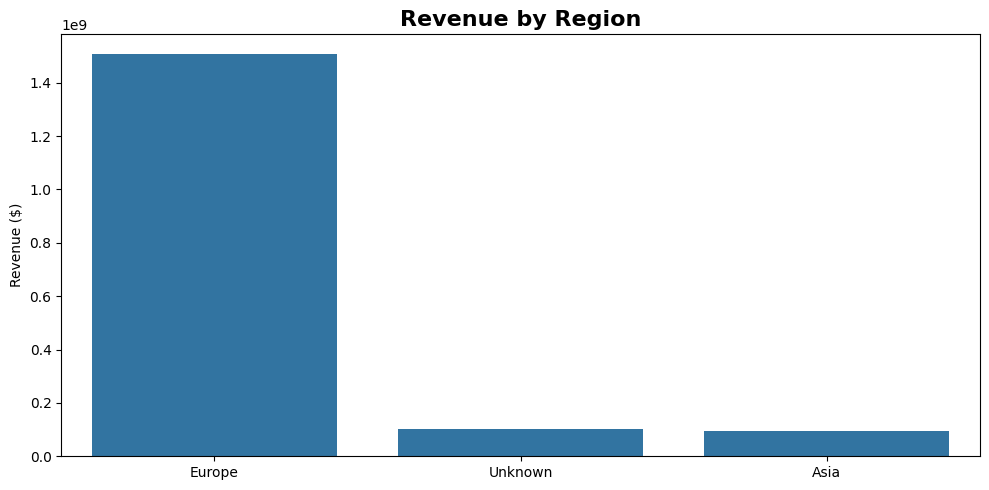

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=region_rev.index, y=region_rev.values)

plt.title("Revenue by Region", fontsize=16, weight="bold")
plt.ylabel("Revenue ($)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Revenue Concentration by Region

Europe represents the company’s primary revenue source, vastly outperforming Asia. This suggests a strong commercial presence and customer base in the European market, while Asia remains a smaller secondary region with growth potential.

A portion of revenue is linked to transactions with missing geographic information (`Unknown`), highlighting an opportunity to improve data governance.

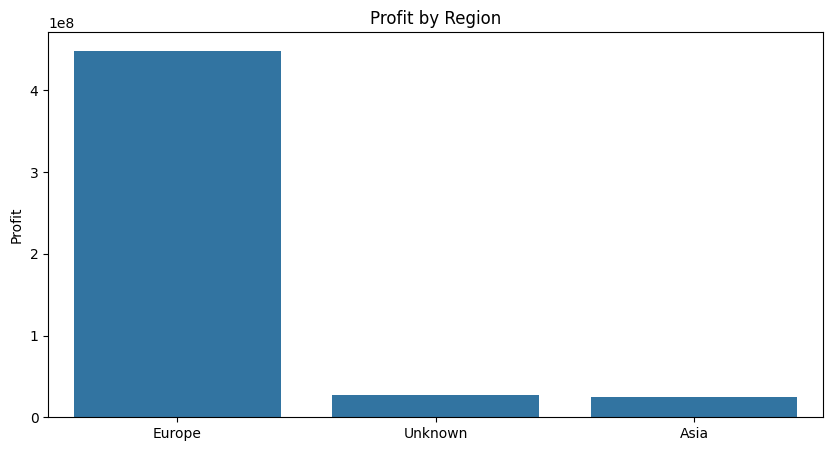

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.xlabel("")
plt.show()

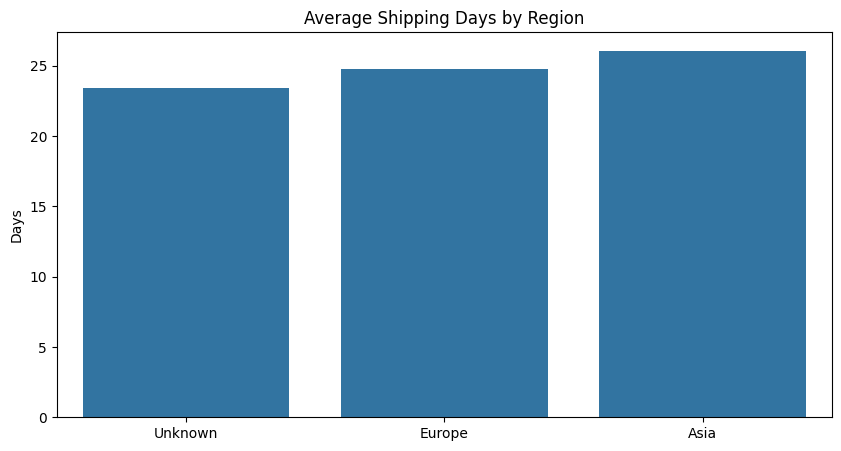

In [ ]:
shipping_region = df.groupby("Region")["Shipping Days"].mean().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=shipping_region.index, y=shipping_region.values)
plt.title("Average Shipping Days by Region")
plt.ylabel("Days")
plt.xlabel("")
plt.show()

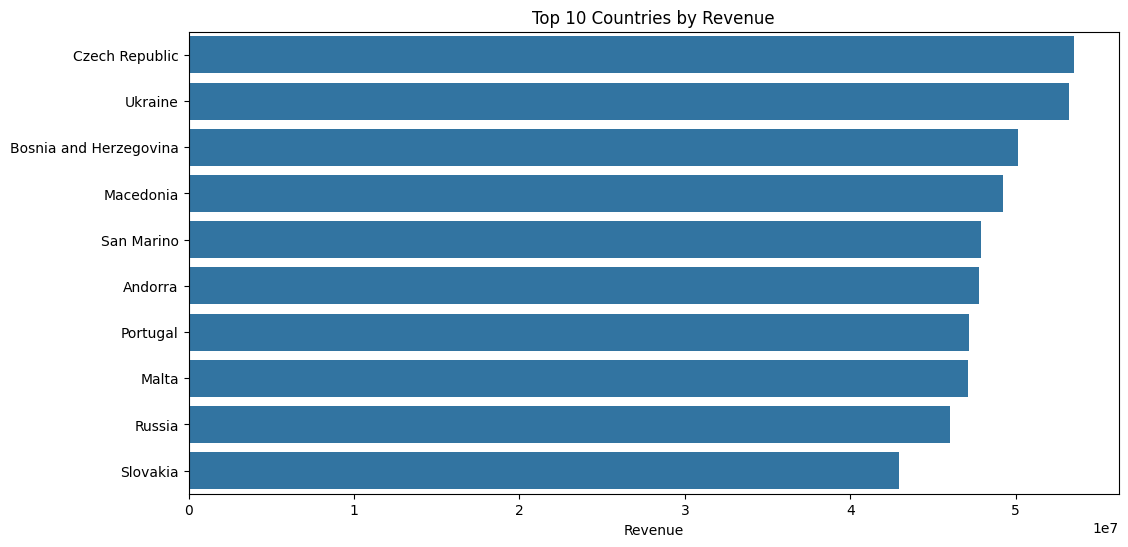

In [ ]:
top_countries = df[df["Country"] != "Unknown"].groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("")
plt.show()

Europe dominates both revenue and profitability, reflecting the company’s strongest commercial presence. Asia represents a smaller but relevant secondary market. Transactions with missing country information were isolated as `Unknown` for transparency.

## Shipping Efficiency vs Profitability

This analysis investigates whether longer shipping times are associated with lower profitability.

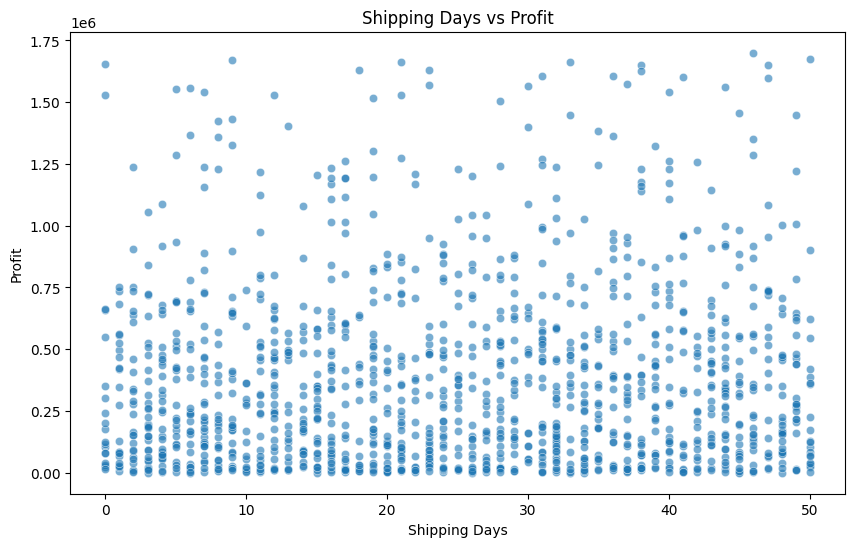

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Shipping Days", y="Profit", alpha=0.6)

plt.title("Shipping Days vs Profit")
plt.xlabel("Shipping Days")
plt.ylabel("Profit")
plt.show()

In [ ]:
group_profit = df.groupby("Shipping Group", observed=False)["Profit"].mean()

print(group_profit)

Shipping Group
1-7      345122.951117
8-14     352025.546118
15-21    374602.997588
22-30    367868.717330
31+      404584.102917
Name: Profit, dtype: float64


### Shipping Time and Profitability

Contrary to expectations, longer shipping times were associated with higher average profit. Orders shipped in more than 31 days generated the highest average profitability.

This suggests that shipping duration may be linked to factors such as larger order sizes, international destinations, or premium product categories rather than operational inefficiency alone.

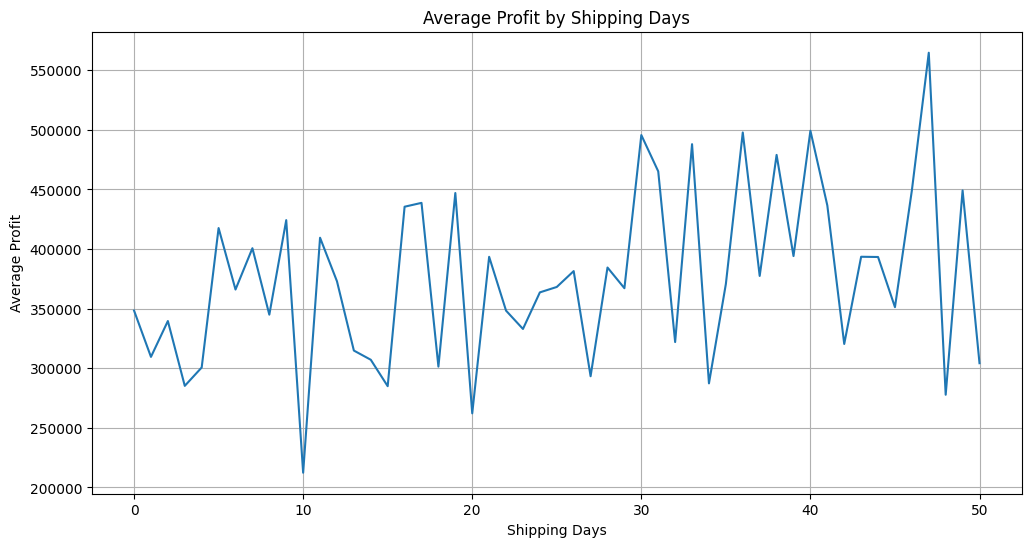

In [ ]:
shipping_profit = df.groupby("Shipping Days")["Profit"].mean()

plt.figure(figsize=(12,6))
shipping_profit.plot()

plt.title("Average Profit by Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Average Profit")
plt.grid(True)
plt.show()

/tmp/ipykernel_3839/4241304158.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_profit = df.groupby("Shipping Group")["Profit"].mean()


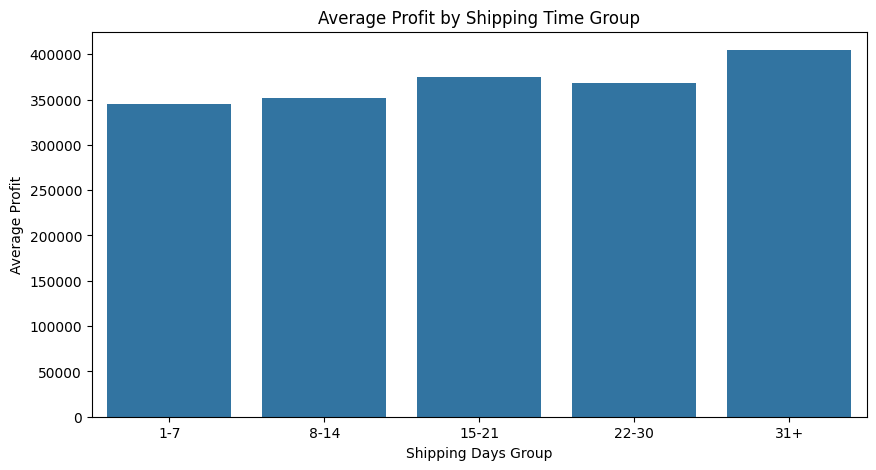

In [ ]:
df["Shipping Group"] = pd.cut(
    df["Shipping Days"],
    bins=[0,7,14,21,30,60],
    labels=["1-7","8-14","15-21","22-30","31+"]
)

group_profit = df.groupby("Shipping Group")["Profit"].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=group_profit.index, y=group_profit.values)

plt.title("Average Profit by Shipping Time Group")
plt.xlabel("Shipping Days Group")
plt.ylabel("Average Profit")
plt.show()

## Sales Trends Over Time

This section analyzes revenue performance across years and months to identify growth patterns, seasonality, and commercial trends.

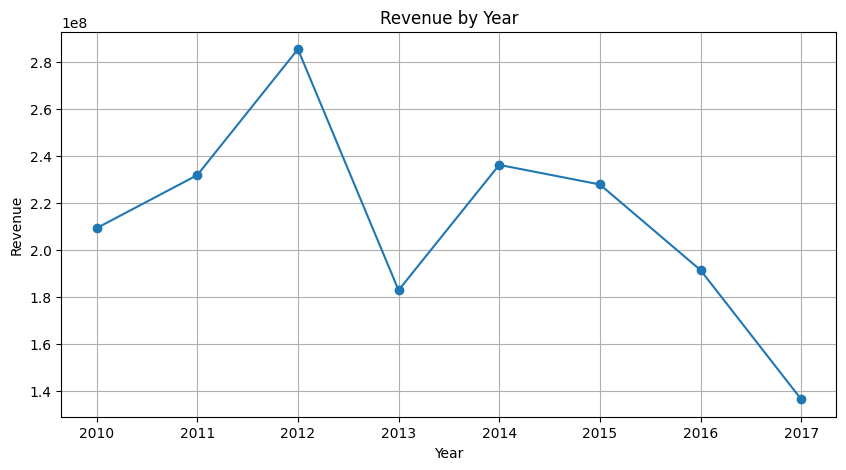

In [ ]:
year_rev = df.groupby("Year")["Revenue"].sum()

plt.figure(figsize=(10,5))
year_rev.plot(marker="o")

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

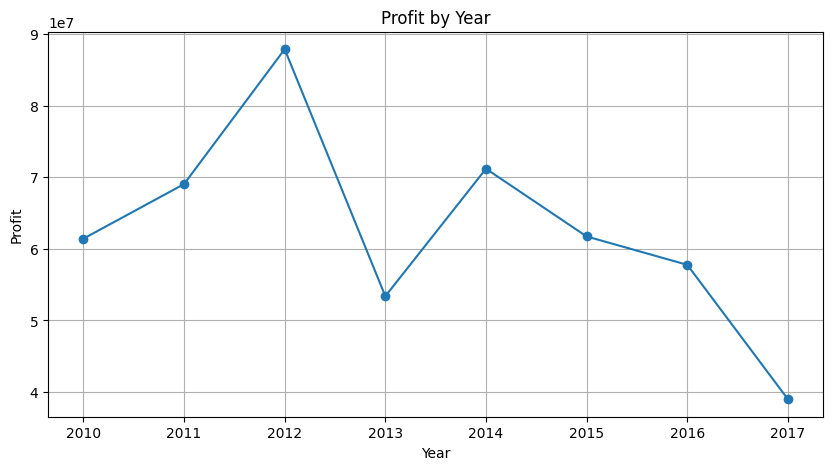

In [ ]:
year_profit = df.groupby("Year")["Profit"].sum()

plt.figure(figsize=(10,5))
year_profit.plot(marker="o")

plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

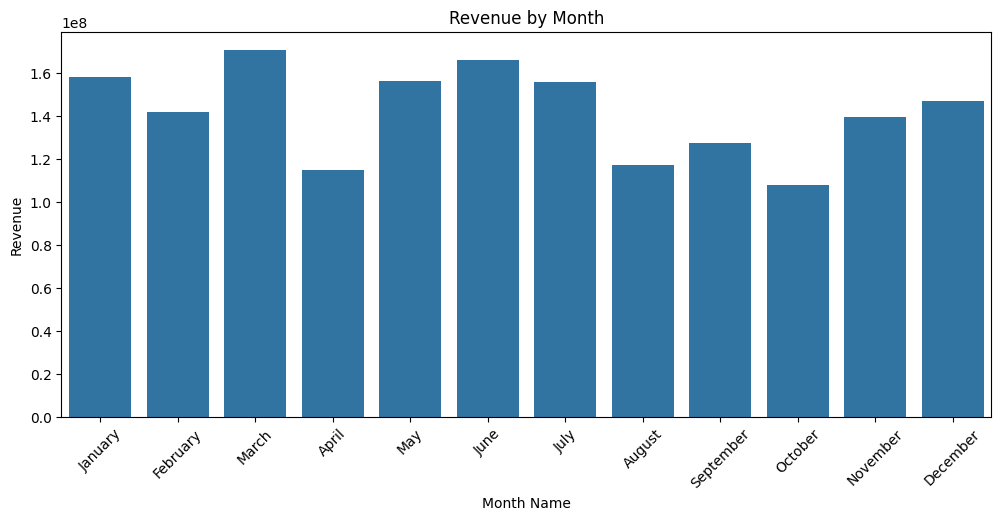

In [ ]:
month_rev = df.groupby("Month Name")["Revenue"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

month_rev = month_rev.reindex(month_order)

plt.figure(figsize=(12,5))
sns.barplot(x=month_rev.index, y=month_rev.values)

plt.title("Revenue by Month")
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.show()

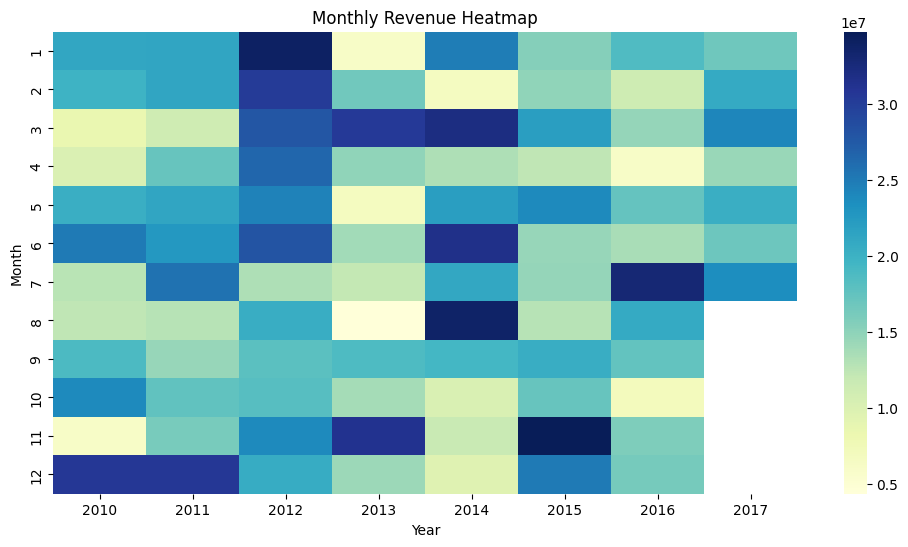

In [ ]:
pivot = df.pivot_table(
    values="Revenue",
    index="Month",
    columns="Year",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)

plt.title("Monthly Revenue Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

## Key Time-Series Findings

- Revenue peaked in **2012**, representing the strongest commercial year in the dataset.
- From **2014 onward**, the company experienced a sustained downward trend through 2017.
- The strongest sales months were **January, March, and June**, suggesting recurring seasonal demand patterns.

/tmp/ipykernel_3839/3806615584.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby("Order Date")["Revenue"].sum().resample("M").sum()


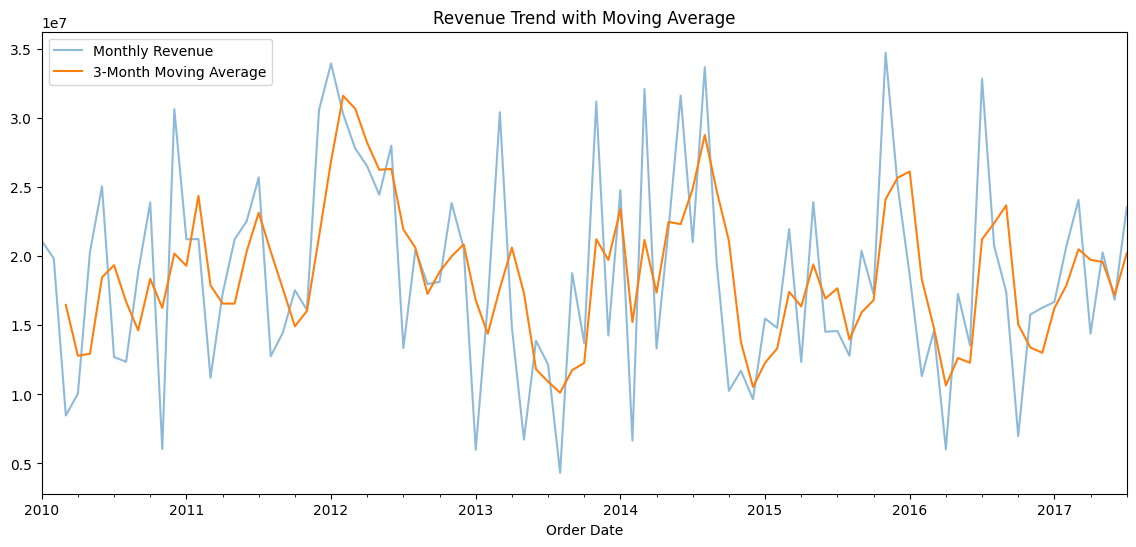

In [ ]:
monthly = df.groupby("Order Date")["Revenue"].sum().resample("M").sum()

rolling = monthly.rolling(3).mean()

plt.figure(figsize=(14,6))
monthly.plot(label="Monthly Revenue", alpha=0.5)
rolling.plot(label="3-Month Moving Average")

plt.title("Revenue Trend with Moving Average")
plt.legend()
plt.show()

## Sales Performance by Day of Week

This section explores how revenue and product demand vary throughout the week, helping identify recurring customer behavior patterns.

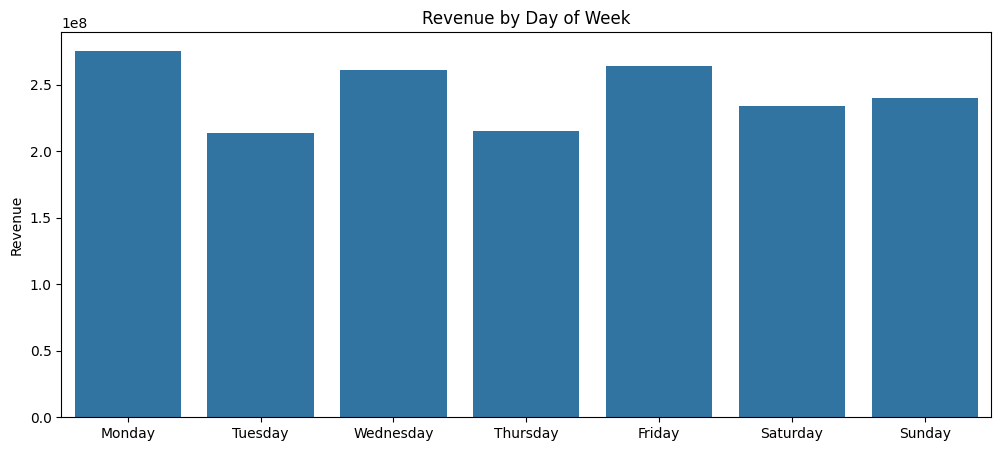

In [ ]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

day_rev = df.groupby("Day Name")["Revenue"].sum().reindex(day_order)

plt.figure(figsize=(12,5))
sns.barplot(x=day_rev.index, y=day_rev.values)

plt.title("Revenue by Day of Week")
plt.ylabel("Revenue")
plt.xlabel("")
plt.show()

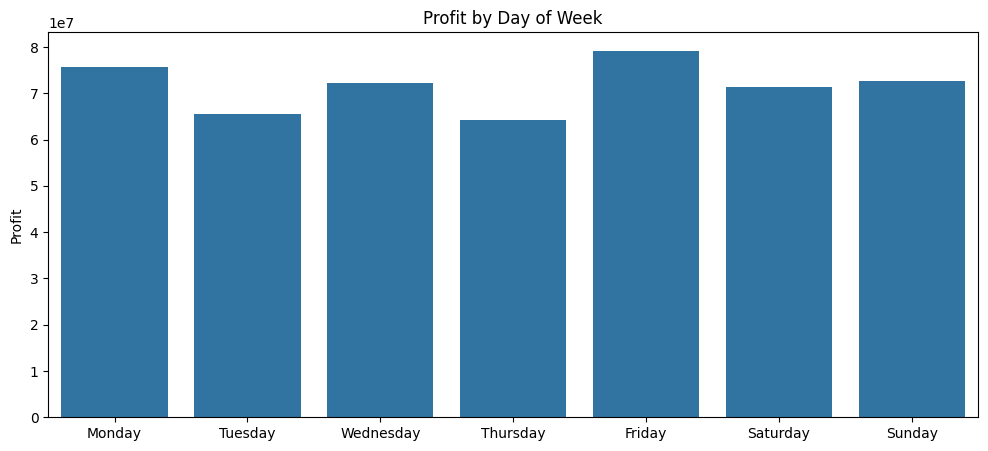

In [ ]:
day_profit = df.groupby("Day Name")["Profit"].sum().reindex(day_order)

plt.figure(figsize=(12,5))
sns.barplot(x=day_profit.index, y=day_profit.values)

plt.title("Profit by Day of Week")
plt.ylabel("Profit")
plt.xlabel("")
plt.show()

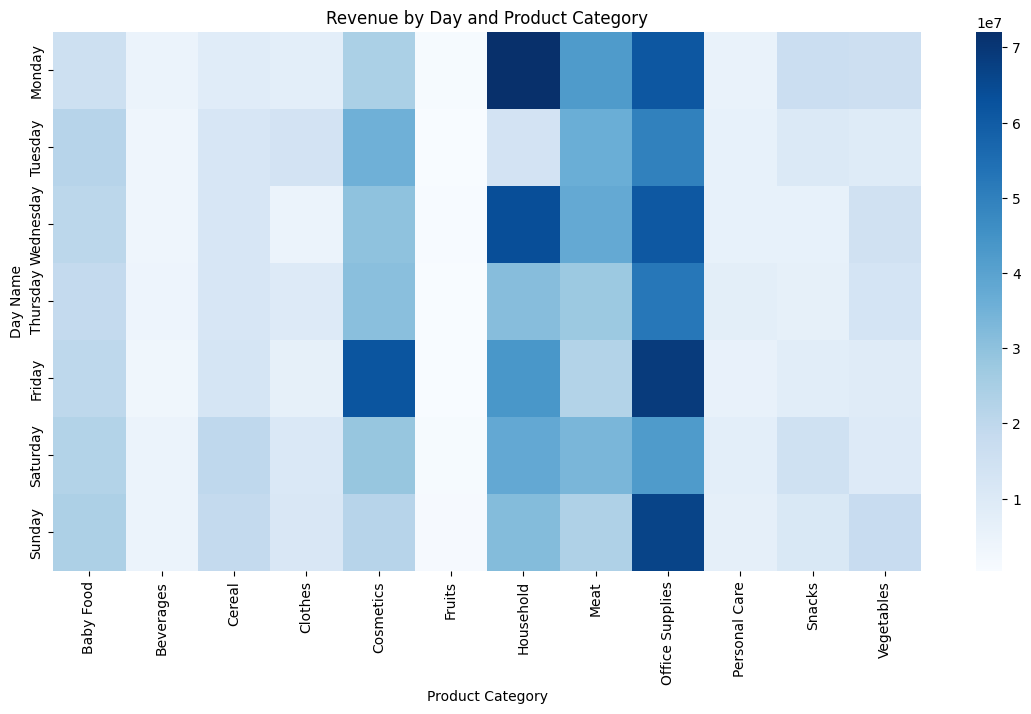

In [ ]:
top_day_product = df.pivot_table(
    values="Revenue",
    index="Day Name",
    columns="Product Category",
    aggfunc="sum"
).reindex(day_order)

plt.figure(figsize=(14,7))
sns.heatmap(top_day_product, cmap="Blues")

plt.title("Revenue by Day and Product Category")
plt.show()

In [ ]:
best_each_day = (
    df.groupby(["Day Name","Product Category"])["Revenue"]
    .sum()
    .reset_index()
)

best_each_day = best_each_day.loc[
    best_each_day.groupby("Day Name")["Revenue"].idxmax()
]

best_each_day = best_each_day.set_index("Day Name").reindex(day_order)

best_each_day

,Product Category,Revenue
Day Name,,
Monday,Household,72058885.83
Tuesday,Office Supplies,49799982.33
Wednesday,Household,63859881.20
Thursday,Office Supplies,52367052.15
Friday,Office Supplies,68955324.48
Saturday,Office Supplies,42309764.91
Sunday,Office Supplies,66650692.29


## Weekly Sales Behavior

- **Monday** generated the highest revenue, suggesting strong start-of-week purchasing activity.
- **Saturday** showed the lowest revenue, indicating weaker commercial demand during weekends.
- **Office Supplies** remained dominant even on weekends, highlighting stable and recurring demand across the week.

Possible business actions:

- Increase Monday inventory readiness and logistics capacity.
- Launch promotional campaigns on Saturdays to stimulate weaker demand.
- Maintain strong availability of Office Supplies throughout the week.

## Sales Channel Performance

This section compares revenue and profitability between Online and Offline sales channels.

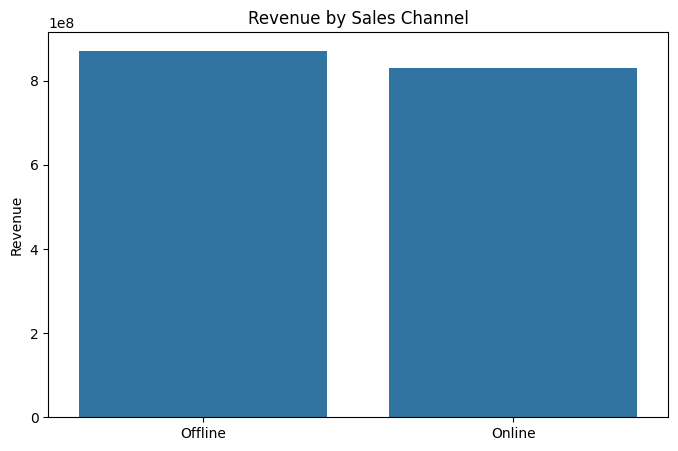

In [ ]:
channel_rev = df.groupby("Sales Channel")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=channel_rev.index, y=channel_rev.values)

plt.title("Revenue by Sales Channel")
plt.xlabel("")
plt.ylabel("Revenue")
plt.show()

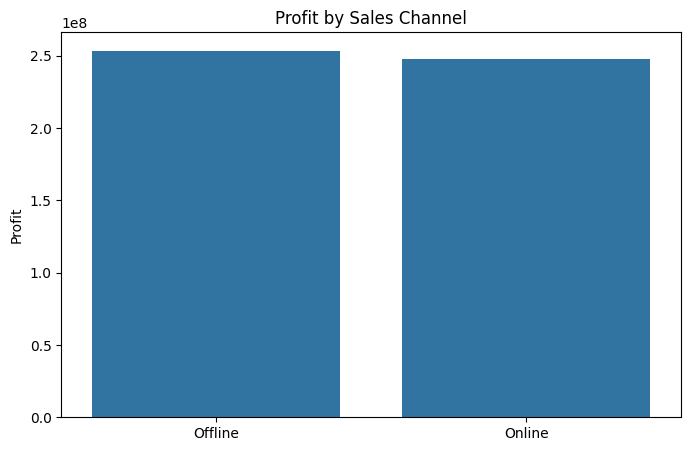

In [ ]:
channel_profit = df.groupby("Sales Channel")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=channel_profit.index, y=channel_profit.values)

plt.title("Profit by Sales Channel")
plt.xlabel("")
plt.ylabel("Profit")
plt.show()

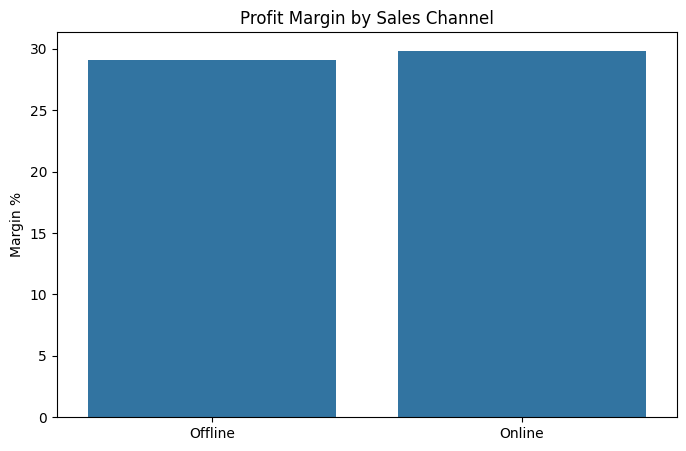

In [ ]:
channel_metrics = df.groupby("Sales Channel")[["Revenue","Profit"]].sum()
channel_metrics["Margin %"] = (channel_metrics["Profit"] / channel_metrics["Revenue"]) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=channel_metrics.index, y=channel_metrics["Margin %"])

plt.title("Profit Margin by Sales Channel")
plt.xlabel("")
plt.ylabel("Margin %")
plt.show()

Online and Offline channels show distinct financial performance patterns. Comparing revenue, profit, and margins helps identify the most efficient commercial channel and supports future channel investment decisions.

## Sales Channel Insights

- Offline sales generated slightly higher revenue than Online sales, indicating that physical channels still represent an important share of the business.
- Profit distribution closely followed revenue performance, suggesting similar profitability dynamics between both channels.
- Online sales achieved a slightly higher profit margin, which may reflect lower operating costs or more efficient commercial processes.

Possible business actions:

- Maintain Offline presence as a stable revenue source.
- Expand Online operations due to stronger margin efficiency.
- Integrate both channels through omnichannel strategies.

# Final Business Conclusions

## Executive Summary

This analysis evaluated the company’s historical global sales performance using transactional, product, and geographic data.

### Key Findings

- The business generated strong total revenue and profitability, with a healthy commercial scale.
- **Europe** is the company’s dominant market, significantly outperforming Asia in sales volume.
- **Office Supplies** led total revenue, while **Cosmetics** delivered the highest profit.
- **Meat** had the lowest profit margin, suggesting lower efficiency or pricing pressure.
- Revenue peaked in **2012**, followed by a sustained decline from **2014 to 2017**.
- The strongest sales months were **January, March, and June**, indicating recurring seasonal demand.
- **Monday** was the highest-performing weekday, while **Saturday** had the weakest revenue.
- Orders with longer shipping times showed higher average profit, likely associated with larger or more complex transactions.

### Strategic Recommendations

- Protect and expand the European market while developing growth strategies for Asia.
- Increase investment in high-margin categories such as Cosmetics.
- Review pricing and cost structure of low-margin categories such as Meat.
- Use seasonal peaks (January, March, June) for targeted campaigns and promotions.
- Strengthen Monday operational capacity and improve weekend demand generation.
- Improve data governance to reduce transactions with missing geographic information.

## Skills Demonstrated

- Data Cleaning and Preparation
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Intelligence Thinking
- KPI Development
- Trend and Seasonality Analysis
- Strategic Insight Generation
- Python (Pandas, Matplotlib, Seaborn)